In [1]:
pip install pandas numpy matplotlib seaborn plotly openpyxl

  Obtaining dependency information for openpyxl from https://files.pythonhosted.org/packages/c0/da/977ded879c29cbd04de313843e76868e6e13408a94ed6b987245dc7c8506/openpyxl-3.1.5-py2.py3-none-any.whl.metadata
  Using cached openpyxl-3.1.5-py2.py3-none-any.whl.metadata (2.5 kB)
  Obtaining dependency information for et-xmlfile from https://files.pythonhosted.org/packages/c1/8b/5fe2cc11fee489817272089c4203e679c63b570a5aaeb18d852ae3cbba6a/et_xmlfile-2.0.0-py3-none-any.whl.metadata
  Using cached et_xmlfile-2.0.0-py3-none-any.whl.metadata (2.7 kB)
Using cached openpyxl-3.1.5-py2.py3-none-any.whl (250 kB)
Using cached et_xmlfile-2.0.0-py3-none-any.whl (18 kB)
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 23.2.1 -> 26.1.2
[notice] To update, run: C:\Users\Fayaz\AppData\Local\Programs\Python\Python311\python.exe -m pip install --upgrade pip


In [5]:
# ==========================================
# Retail Sales Performance Analysis
# Import Required Libraries
# ==========================================

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import plotly.express as px

import warnings
warnings.filterwarnings("ignore")

# Display all columns
pd.set_option("display.max_columns", None)

# Display wider tables
pd.set_option("display.width", 1000)

print("Libraries Imported Successfully!")

Libraries Imported Successfully!


In [10]:
import os

# Project folders
folders = [
    "data",
    "notebook",
    "output",
    "dashboard",
    "sql",
    "images"
]

# Create folders
for folder in folders:
    os.makedirs(folder, exist_ok=True)

print("✅ Project folders created successfully!")

# Show created folders
print("\nCurrent project folders:")
print(os.listdir())

✅ Project folders created successfully!

Current project folders:
[' Retail_Sales_Analysis.ipynb', '.ipynb_checkpoints', 'dashboard', 'data', 'images', 'notebook', 'output', 'sql']


In [12]:
# Load Dataset

df = pd.read_csv("data/SampleSuperstore.csv.zip")

print("Dataset Loaded Successfully!")

Dataset Loaded Successfully!


In [13]:
# Display first five rows

df.head()

,Ship Mode,Segment,Country,City,State,Postal Code,Region,Category,Sub-Category,Sales,Quantity,Discount,Profit
0,Second Class,Consumer,United States,Henderson,Kentucky,42420,South,Furniture,Bookcases,261.9600,2,0.00,41.9136
1,Second Class,Consumer,United States,Henderson,Kentucky,42420,South,Furniture,Chairs,731.9400,3,0.00,219.5820
2,Second Class,Corporate,United States,Los Angeles,California,90036,West,Office Supplies,Labels,14.6200,2,0.00,6.8714
3,Standard Class,Consumer,United States,Fort Lauderdale,Florida,33311,South,Furniture,Tables,957.5775,5,0.45,-383.0310
4,Standard Class,Consumer,United States,Fort Lauderdale,Florida,33311,South,Office Supplies,Storage,22.3680,2,0.20,2.5164


In [14]:
# Display last five rows

df.tail()

,Ship Mode,Segment,Country,City,State,Postal Code,Region,Category,Sub-Category,Sales,Quantity,Discount,Profit
9989,Second Class,Consumer,United States,Miami,Florida,33180,South,Furniture,Furnishings,25.248,3,0.2,4.1028
9990,Standard Class,Consumer,United States,Costa Mesa,California,92627,West,Furniture,Furnishings,91.960,2,0.0,15.6332
9991,Standard Class,Consumer,United States,Costa Mesa,California,92627,West,Technology,Phones,258.576,2,0.2,19.3932
9992,Standard Class,Consumer,United States,Costa Mesa,California,92627,West,Office Supplies,Paper,29.600,4,0.0,13.3200
9993,Second Class,Consumer,United States,Westminster,California,92683,West,Office Supplies,Appliances,243.160,2,0.0,72.9480


In [15]:
# Number of rows and columns

print("Shape of Dataset:")
print(df.shape)

Shape of Dataset:
(9994, 13)


In [16]:
# Display column names

print(df.columns)

Index(['Ship Mode', 'Segment', 'Country', 'City', 'State', 'Postal Code', 'Region', 'Category', 'Sub-Category', 'Sales', 'Quantity', 'Discount', 'Profit'], dtype='str')


In [17]:
# Information about dataset

df.info()

<class 'pandas.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 13 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Ship Mode     9994 non-null   str    
 1   Segment       9994 non-null   str    
 2   Country       9994 non-null   str    
 3   City          9994 non-null   str    
 4   State         9994 non-null   str    
 5   Postal Code   9994 non-null   int64  
 6   Region        9994 non-null   str    
 7   Category      9994 non-null   str    
 8   Sub-Category  9994 non-null   str    
 9   Sales         9994 non-null   float64
 10  Quantity      9994 non-null   int64  
 11  Discount      9994 non-null   float64
 12  Profit        9994 non-null   float64
dtypes: float64(3), int64(2), str(8)
memory usage: 1015.1 KB


In [18]:
# Data types

df.dtypes

Ship Mode           str
Segment             str
Country             str
City                str
State               str
Postal Code       int64
Region              str
Category            str
Sub-Category        str
Sales           float64
Quantity          int64
Discount        float64
Profit          float64
dtype: object

In [19]:
# Statistical Summary

df.describe()

,Postal Code,Sales,Quantity,Discount,Profit
count,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000
mean,55190.379428,229.858001,3.789574,0.156203,28.656896
std,32063.693350,623.245101,2.225110,0.206452,234.260108
min,1040.000000,0.444000,1.000000,0.000000,-6599.978000
25%,23223.000000,17.280000,2.000000,0.000000,1.728750
50%,56430.500000,54.490000,3.000000,0.200000,8.666500
75%,90008.000000,209.940000,5.000000,0.200000,29.364000
max,99301.000000,22638.480000,14.000000,0.800000,8399.976000


In [20]:
# Include object columns

df.describe(include="all")

,Ship Mode,Segment,Country,City,State,Postal Code,Region,Category,Sub-Category,Sales,Quantity,Discount,Profit
count,9994,9994,9994,9994,9994,9994.000000,9994,9994,9994,9994.000000,9994.000000,9994.000000,9994.000000
unique,4,3,1,531,49,NaN,4,3,17,NaN,NaN,NaN,NaN
top,Standard Class,Consumer,United States,New York City,California,NaN,West,Office Supplies,Binders,NaN,NaN,NaN,NaN
freq,5968,5191,9994,915,2001,NaN,3203,6026,1523,NaN,NaN,NaN,NaN
mean,NaN,NaN,NaN,NaN,NaN,55190.379428,NaN,NaN,NaN,229.858001,3.789574,0.156203,28.656896
std,NaN,NaN,NaN,NaN,NaN,32063.693350,NaN,NaN,NaN,623.245101,2.225110,0.206452,234.260108
min,NaN,NaN,NaN,NaN,NaN,1040.000000,NaN,NaN,NaN,0.444000,1.000000,0.000000,-6599.978000
25%,NaN,NaN,NaN,NaN,NaN,23223.000000,NaN,NaN,NaN,17.280000,2.000000,0.000000,1.728750
50%,NaN,NaN,NaN,NaN,NaN,56430.500000,NaN,NaN,NaN,54.490000,3.000000,0.200000,8.666500
75%,NaN,NaN,NaN,NaN,NaN,90008.000000,NaN,NaN,NaN,209.940000,5.000000,0.200000,29.364000


In [21]:
# Missing values

df.isnull().sum()

Ship Mode       0
Segment         0
Country         0
City            0
State           0
Postal Code     0
Region          0
Category        0
Sub-Category    0
Sales           0
Quantity        0
Discount        0
Profit          0
dtype: int64

In [22]:
print("Total Missing Values:", df.isnull().sum().sum())

Total Missing Values: 0


In [23]:
duplicates = df.duplicated().sum()

print("Duplicate Rows:", duplicates)

Duplicate Rows: 17


In [24]:
df = df.drop_duplicates()

print("Duplicates Removed Successfully!")

Duplicates Removed Successfully!


In [26]:
#checks dataset shape again
print(df.shape)

(9977, 13)


In [27]:
#Display Random Records
df.sample(10)

,Ship Mode,Segment,Country,City,State,Postal Code,Region,Category,Sub-Category,Sales,Quantity,Discount,Profit
1595,Standard Class,Consumer,United States,Columbus,Ohio,43229,East,Furniture,Chairs,47.992,2,0.3,-2.0568
2250,Second Class,Consumer,United States,Los Angeles,California,90004,West,Office Supplies,Appliances,541.440,6,0.0,157.0176
4471,Same Day,Home Office,United States,Mentor,Ohio,44060,East,Furniture,Chairs,63.686,1,0.3,-15.4666
6802,Standard Class,Corporate,United States,Phoenix,Arizona,85023,West,Technology,Accessories,100.800,2,0.2,21.4200
5269,Same Day,Consumer,United States,San Francisco,California,94110,West,Furniture,Furnishings,32.360,4,0.0,11.6496
6761,Second Class,Corporate,United States,New York City,New York,10035,East,Furniture,Chairs,253.764,2,0.1,31.0156
694,First Class,Home Office,United States,Chester,Pennsylvania,19013,East,Office Supplies,Art,198.272,8,0.2,17.3488
4232,Standard Class,Corporate,United States,Dallas,Texas,75220,Central,Office Supplies,Paper,31.104,6,0.2,11.2752
9287,Standard Class,Home Office,United States,Dallas,Texas,75081,Central,Furniture,Tables,457.485,3,0.3,-84.9615
5609,Standard Class,Consumer,United States,Monroe,Louisiana,71203,South,Technology,Accessories,659.900,2,0.0,217.7670


In [28]:
#Count Unique Values
df.nunique()

Ship Mode          4
Segment            3
Country            1
City             531
State             49
Postal Code      631
Region             4
Category           3
Sub-Category      17
Sales           5825
Quantity          14
Discount          12
Profit          7287
dtype: int64

In [29]:
#Unique Values of Important Columns
print("Categories")
print(df["Category"].unique())

print()

print("Segments")
print(df["Segment"].unique())

print()

print("Regions")
print(df["Region"].unique())

Categories
<StringArray>
['Furniture', 'Office Supplies', 'Technology']
Length: 3, dtype: str

Segments
<StringArray>
['Consumer', 'Corporate', 'Home Office']
Length: 3, dtype: str

Regions
<StringArray>
['South', 'West', 'Central', 'East']
Length: 4, dtype: str


In [30]:
#Check Sales Column
print(df["Sales"].describe())

count     9977.000000
mean       230.148902
std        623.721409
min          0.444000
25%         17.300000
50%         54.816000
75%        209.970000
max      22638.480000
Name: Sales, dtype: float64


In [31]:
#Check Profit Column
print(df["Profit"].describe())

count    9977.00000
mean       28.69013
std       234.45784
min     -6599.97800
25%         1.72620
50%         8.67100
75%        29.37200
max      8399.97600
Name: Profit, dtype: float64


In [32]:
#Check Quantity Column
print(df["Quantity"].describe())

count    9977.000000
mean        3.790719
std         2.226657
min         1.000000
25%         2.000000
50%         3.000000
75%         5.000000
max        14.000000
Name: Quantity, dtype: float64


In [33]:
#Correlation Matrix (Numeric Columns)
numeric_df = df.select_dtypes(include=np.number)

numeric_df.corr()

,Postal Code,Sales,Quantity,Discount,Profit
Postal Code,1.000000,-0.023476,0.013110,0.059225,-0.029892
Sales,-0.023476,1.000000,0.200722,-0.028311,0.479067
Quantity,0.013110,0.200722,1.000000,0.008678,0.066211
Discount,0.059225,-0.028311,0.008678,1.000000,-0.219662
Profit,-0.029892,0.479067,0.066211,-0.219662,1.000000


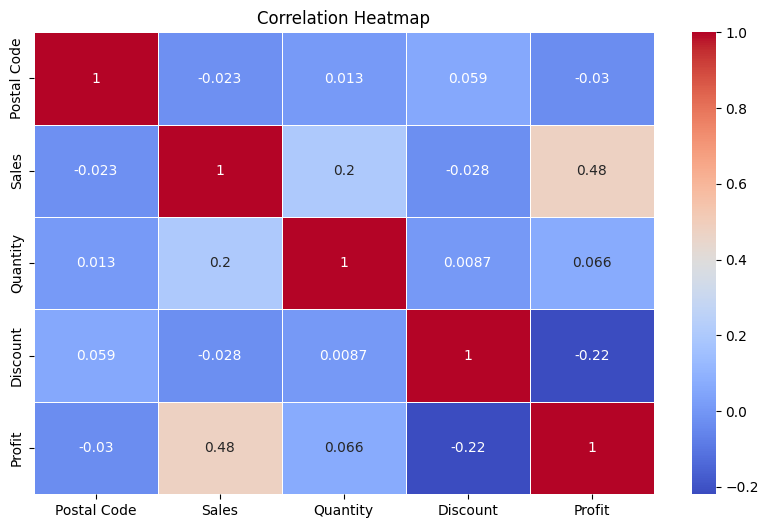

In [34]:
#Correlation Heatmap
plt.figure(figsize=(10,6))

sns.heatmap(
    numeric_df.corr(),
    annot=True,
    cmap="coolwarm",
    linewidths=0.5
)

plt.title("Correlation Heatmap")
plt.show()

In [35]:
df.to_csv("output/cleaned_data.csv", index=False)

print("Cleaned dataset saved successfully!")

Cleaned dataset saved successfully!


In [36]:
import pandas as pd
import numpy as np

# Load cleaned dataset from Section 1
df = pd.read_csv("output/cleaned_data.csv")

print("Dataset Loaded Successfully!")

Dataset Loaded Successfully!


In [37]:
#Data informatin checking
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 9977 entries, 0 to 9976
Data columns (total 13 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Ship Mode     9977 non-null   str    
 1   Segment       9977 non-null   str    
 2   Country       9977 non-null   str    
 3   City          9977 non-null   str    
 4   State         9977 non-null   str    
 5   Postal Code   9977 non-null   int64  
 6   Region        9977 non-null   str    
 7   Category      9977 non-null   str    
 8   Sub-Category  9977 non-null   str    
 9   Sales         9977 non-null   float64
 10  Quantity      9977 non-null   int64  
 11  Discount      9977 non-null   float64
 12  Profit        9977 non-null   float64
dtypes: float64(3), int64(2), str(8)
memory usage: 1013.4 KB


In [38]:
#Display First Five Rows
df.head()

,Ship Mode,Segment,Country,City,State,Postal Code,Region,Category,Sub-Category,Sales,Quantity,Discount,Profit
0,Second Class,Consumer,United States,Henderson,Kentucky,42420,South,Furniture,Bookcases,261.9600,2,0.00,41.9136
1,Second Class,Consumer,United States,Henderson,Kentucky,42420,South,Furniture,Chairs,731.9400,3,0.00,219.5820
2,Second Class,Corporate,United States,Los Angeles,California,90036,West,Office Supplies,Labels,14.6200,2,0.00,6.8714
3,Standard Class,Consumer,United States,Fort Lauderdale,Florida,33311,South,Furniture,Tables,957.5775,5,0.45,-383.0310
4,Standard Class,Consumer,United States,Fort Lauderdale,Florida,33311,South,Office Supplies,Storage,22.3680,2,0.20,2.5164


In [39]:
#Check Missing Values Again
print(df.isnull().sum())

Ship Mode       0
Segment         0
Country         0
City            0
State           0
Postal Code     0
Region          0
Category        0
Sub-Category    0
Sales           0
Quantity        0
Discount        0
Profit          0
dtype: int64


In [43]:
print(df.shape)

(9977, 13)


In [44]:
print(df.dtypes)

Ship Mode           str
Segment             str
Country             str
City                str
State               str
Postal Code       int64
Region              str
Category            str
Sub-Category        str
Sales           float64
Quantity          int64
Discount        float64
Profit          float64
dtype: object


In [45]:
#Clean text columns
text_columns = [
    "Ship Mode",
    "Segment",
    "Country",
    "City",
    "State",
    "Region",
    "Category",
    "Sub-Category"
]

for col in text_columns:
    df[col] = df[col].str.strip().str.title()

print("Text Cleaning Completed")

Text Cleaning Completed


In [46]:
#Chaeck unique values
for col in text_columns:
    print("\n", col)
    print(df[col].unique())


 Ship Mode
<StringArray>
['Second Class', 'Standard Class', 'First Class', 'Same Day']
Length: 4, dtype: str

 Segment
<StringArray>
['Consumer', 'Corporate', 'Home Office']
Length: 3, dtype: str

 Country
<StringArray>
['United States']
Length: 1, dtype: str

 City
<StringArray>
[        'Henderson',       'Los Angeles',   'Fort Lauderdale',           'Concord',           'Seattle',        'Fort Worth',           'Madison',       'West Jordan',     'San Francisco',           'Fremont',
 ...
        'Hagerstown',       'East Orange', 'Arlington Heights',            'Oswego',       'Coon Rapids',      'San Clemente',   'San Luis Obispo',        'Springdale',              'Lodi',             'Mason']
Length: 531, dtype: str

 State
<StringArray>
['Kentucky', 'California', 'Florida', 'North Carolina', 'Washington', 'Texas', 'Wisconsin', 'Utah', 'Nebraska', 'Pennsylvania', 'Illinois', 'Minnesota', 'Michigan', 'Delaware', 'Indiana', 'New York', 'Arizona', 'Virginia', 'Tennessee', 'Alabama'

In [47]:
#Check Numeric Columns
numeric_columns = [
    "Sales",
    "Quantity",
    "Discount",
    "Profit"
]

print(df[numeric_columns].describe())

              Sales     Quantity     Discount      Profit
count   9977.000000  9977.000000  9977.000000  9977.00000
mean     230.148902     3.790719     0.156278    28.69013
std      623.721409     2.226657     0.206455   234.45784
min        0.444000     1.000000     0.000000 -6599.97800
25%       17.300000     2.000000     0.000000     1.72620
50%       54.816000     3.000000     0.200000     8.67100
75%      209.970000     5.000000     0.200000    29.37200
max    22638.480000    14.000000     0.800000  8399.97600


In [48]:
duplicates = df.duplicated().sum()

print("Duplicate Rows:", duplicates)

Duplicate Rows: 0


In [49]:
df = df.drop_duplicates()

print("Duplicates Removed Successfully")

Duplicates Removed Successfully


In [50]:
#Detect outliers
for column in numeric_columns:

    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)

    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    outliers = df[(df[column] < lower) | (df[column] > upper)]

    print(column, ":", len(outliers))

Sales : 1167
Quantity : 170
Discount : 855
Profit : 1881


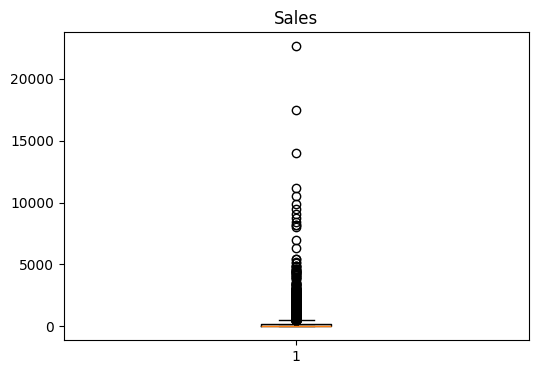

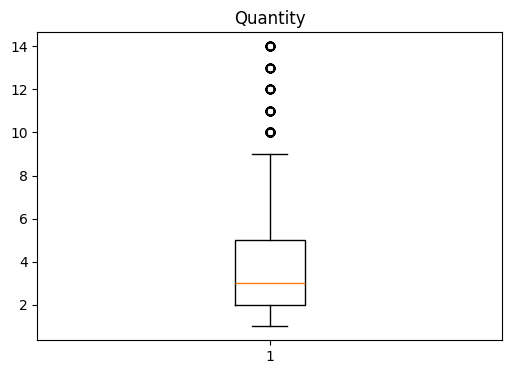

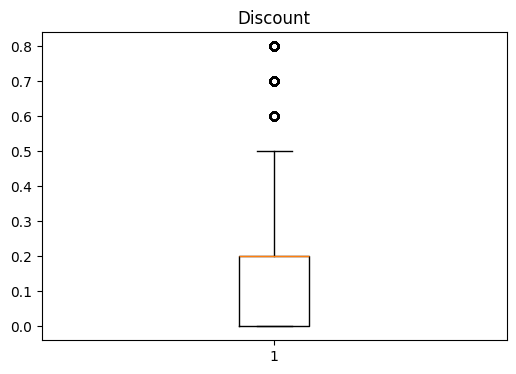

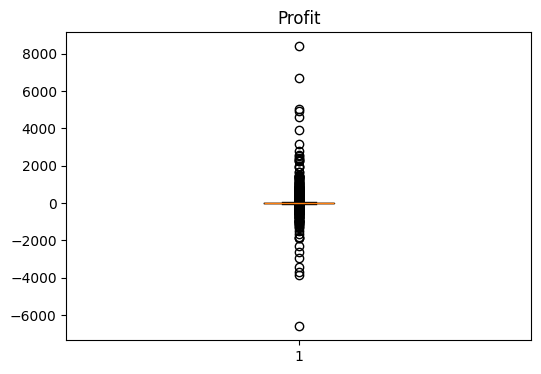

In [51]:
#Boxplot
for column in numeric_columns:

    plt.figure(figsize=(6,4))

    plt.boxplot(df[column])

    plt.title(column)

    plt.show()

In [52]:
#Create Profit Margin
df["Profit Margin"] = (df["Profit"] / df["Sales"]) * 100

df["Profit Margin"] = df["Profit Margin"].round(2)

df.head()

,Ship Mode,Segment,Country,City,State,Postal Code,Region,Category,Sub-Category,Sales,Quantity,Discount,Profit,Profit Margin
0,Second Class,Consumer,United States,Henderson,Kentucky,42420,South,Furniture,Bookcases,261.9600,2,0.00,41.9136,16.00
1,Second Class,Consumer,United States,Henderson,Kentucky,42420,South,Furniture,Chairs,731.9400,3,0.00,219.5820,30.00
2,Second Class,Corporate,United States,Los Angeles,California,90036,West,Office Supplies,Labels,14.6200,2,0.00,6.8714,47.00
3,Standard Class,Consumer,United States,Fort Lauderdale,Florida,33311,South,Furniture,Tables,957.5775,5,0.45,-383.0310,-40.00
4,Standard Class,Consumer,United States,Fort Lauderdale,Florida,33311,South,Office Supplies,Storage,22.3680,2,0.20,2.5164,11.25


In [53]:
#Create Sales Category
df["Sales Category"] = pd.cut(
    df["Sales"],
    bins=[0,100,500,1000,25000],
    labels=["Low","Medium","High","Very High"]
)

df.head()

,Ship Mode,Segment,Country,City,State,Postal Code,Region,Category,Sub-Category,Sales,Quantity,Discount,Profit,Profit Margin,Sales Category
0,Second Class,Consumer,United States,Henderson,Kentucky,42420,South,Furniture,Bookcases,261.9600,2,0.00,41.9136,16.00,Medium
1,Second Class,Consumer,United States,Henderson,Kentucky,42420,South,Furniture,Chairs,731.9400,3,0.00,219.5820,30.00,High
2,Second Class,Corporate,United States,Los Angeles,California,90036,West,Office Supplies,Labels,14.6200,2,0.00,6.8714,47.00,Low
3,Standard Class,Consumer,United States,Fort Lauderdale,Florida,33311,South,Furniture,Tables,957.5775,5,0.45,-383.0310,-40.00,High
4,Standard Class,Consumer,United States,Fort Lauderdale,Florida,33311,South,Office Supplies,Storage,22.3680,2,0.20,2.5164,11.25,Low


In [54]:
#Create Sales Category
df.replace([np.inf, -np.inf], np.nan, inplace=True)

print(df.isnull().sum())

Ship Mode         0
Segment           0
Country           0
City              0
State             0
Postal Code       0
Region            0
Category          0
Sub-Category      0
Sales             0
Quantity          0
Discount          0
Profit            0
Profit Margin     0
Sales Category    0
dtype: int64


In [55]:
#Fill Missing Profit Margin
df["Profit Margin"] = df["Profit Margin"].fillna(0)

In [56]:
#Check Final Dataset
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 9977 entries, 0 to 9976
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype   
---  ------          --------------  -----   
 0   Ship Mode       9977 non-null   str     
 1   Segment         9977 non-null   str     
 2   Country         9977 non-null   str     
 3   City            9977 non-null   str     
 4   State           9977 non-null   str     
 5   Postal Code     9977 non-null   int64   
 6   Region          9977 non-null   str     
 7   Category        9977 non-null   str     
 8   Sub-Category    9977 non-null   str     
 9   Sales           9977 non-null   float64 
 10  Quantity        9977 non-null   int64   
 11  Discount        9977 non-null   float64 
 12  Profit          9977 non-null   float64 
 13  Profit Margin   9977 non-null   float64 
 14  Sales Category  9977 non-null   category
dtypes: category(1), float64(4), int64(2), str(8)
memory usage: 1.1 MB


In [57]:
df.to_csv("output/preprocessed_data.csv", index=False)

print("Preprocessed Dataset Saved Successfully")

Preprocessed Dataset Saved Successfully


In [58]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("ggplot")

In [59]:
df = pd.read_csv("output/preprocessed_data.csv")

print("Dataset Loaded Successfully!")

Dataset Loaded Successfully!


In [60]:
total_sales = df["Sales"].sum()

print("Total Sales : ${:,.2f}".format(total_sales))

Total Sales : $2,296,195.59


In [61]:
total_profit = df["Profit"].sum()

print("Total Profit : ${:,.2f}".format(total_profit))

Total Profit : $286,241.42


In [62]:
total_quantity = df["Quantity"].sum()

print("Total Quantity :", total_quantity)

Total Quantity : 37820


In [63]:
print("Average Sales :", round(df["Sales"].mean(),2))

Average Sales : 230.15


In [64]:
print("Average Profit :", round(df["Profit"].mean(),2))

Average Profit : 28.69


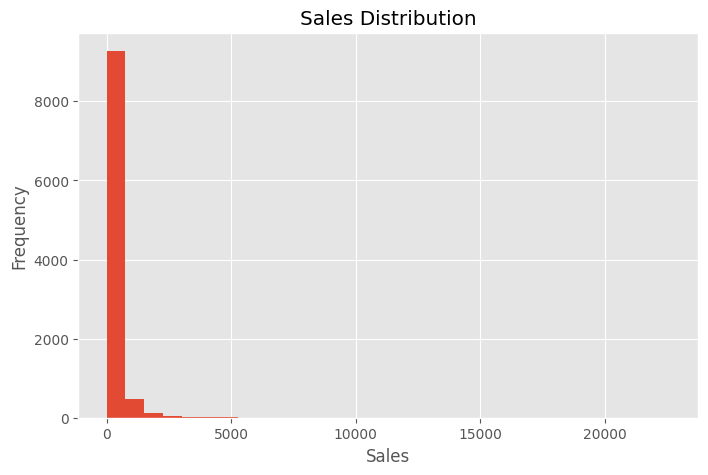

In [65]:
plt.figure(figsize=(8,5))

plt.hist(df["Sales"], bins=30)

plt.title("Sales Distribution")

plt.xlabel("Sales")

plt.ylabel("Frequency")

plt.show()

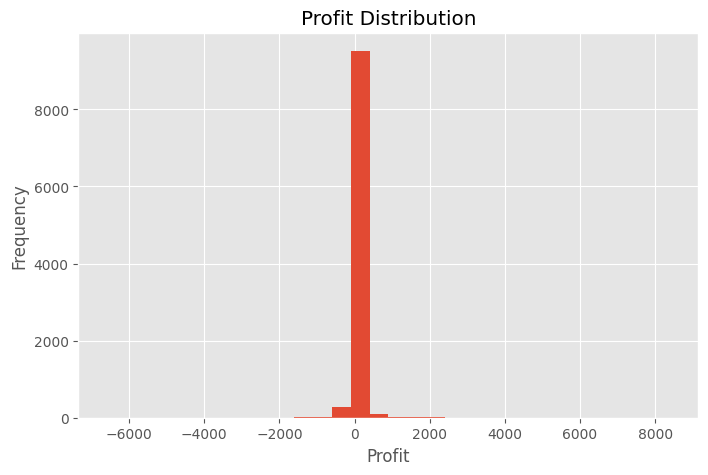

In [66]:
plt.figure(figsize=(8,5))

plt.hist(df["Profit"], bins=30)

plt.title("Profit Distribution")

plt.xlabel("Profit")

plt.ylabel("Frequency")

plt.show()

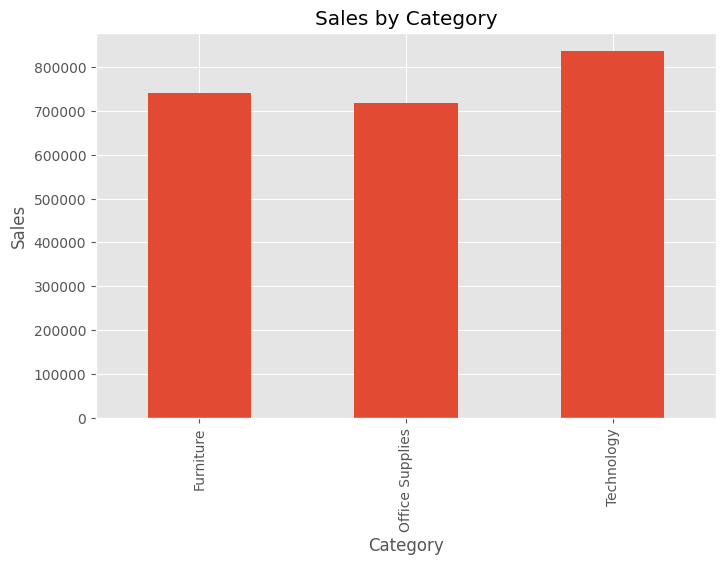

In [67]:
category_sales = df.groupby("Category")["Sales"].sum()

category_sales.plot(kind="bar", figsize=(8,5))

plt.title("Sales by Category")

plt.ylabel("Sales")

plt.show()

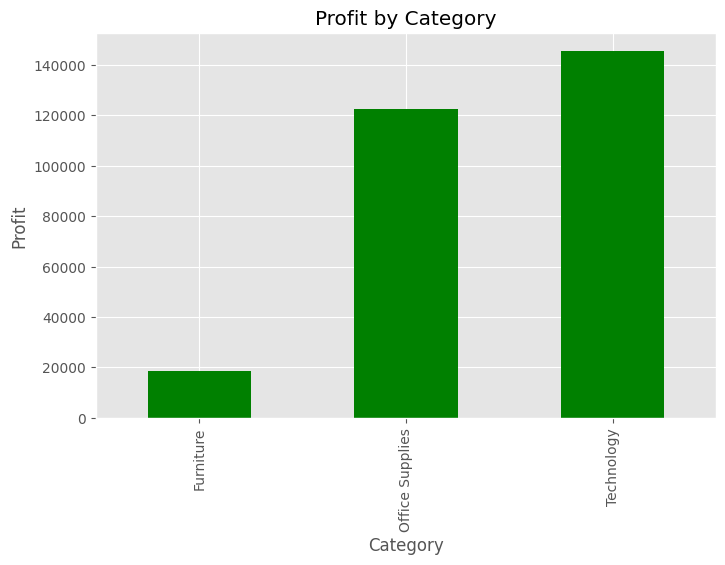

In [68]:
category_profit = df.groupby("Category")["Profit"].sum()

category_profit.plot(kind="bar", figsize=(8,5), color="green")

plt.title("Profit by Category")

plt.ylabel("Profit")

plt.show()

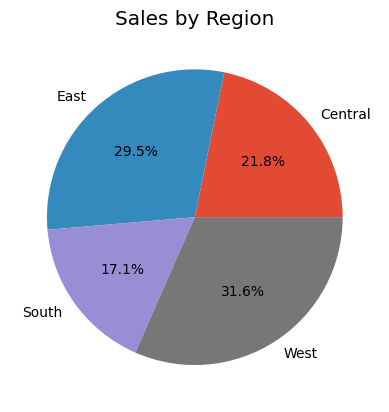

In [69]:
region_sales = df.groupby("Region")["Sales"].sum()

region_sales.plot(kind="pie", autopct="%1.1f%%")

plt.title("Sales by Region")

plt.ylabel("")

plt.show()

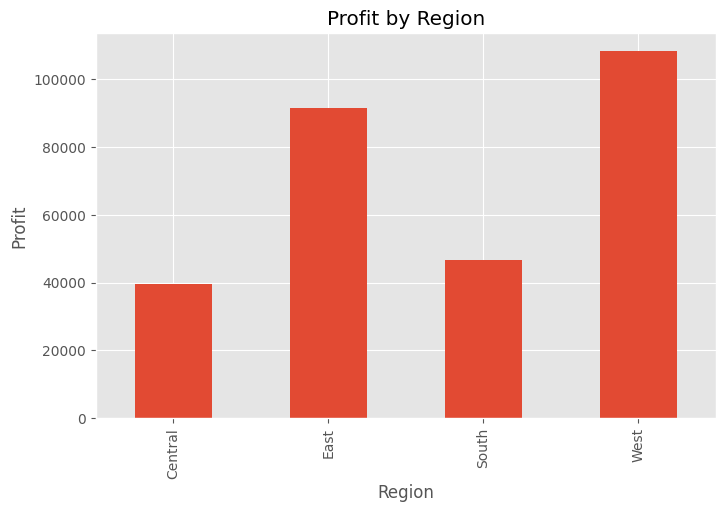

In [70]:
region_profit = df.groupby("Region")["Profit"].sum()

region_profit.plot(kind="bar", figsize=(8,5))

plt.title("Profit by Region")

plt.ylabel("Profit")

plt.show()

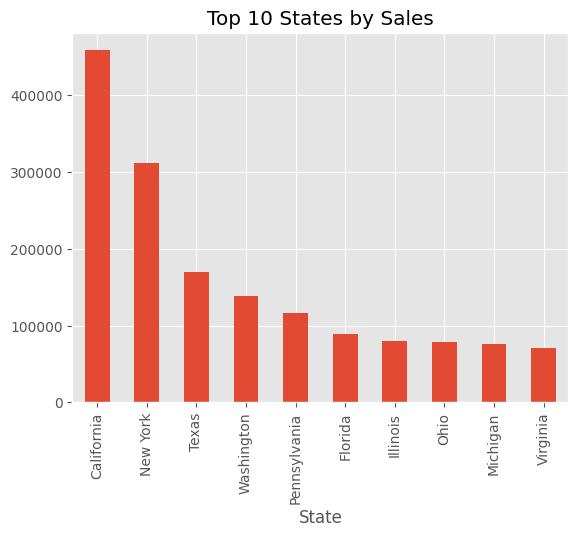

In [71]:
top_states = df.groupby("State")["Sales"].sum().sort_values(ascending=False).head(10)

top_states.plot(kind="bar")

plt.title("Top 10 States by Sales")

plt.show()

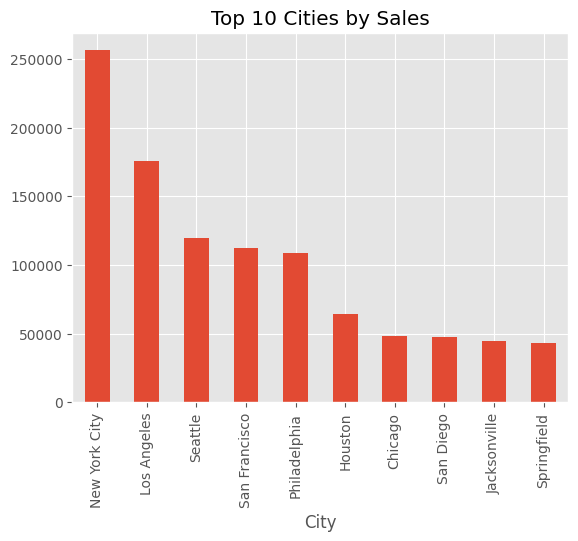

In [72]:
top_cities = df.groupby("City")["Sales"].sum().sort_values(ascending=False).head(10)

top_cities.plot(kind="bar")

plt.title("Top 10 Cities by Sales")

plt.show()

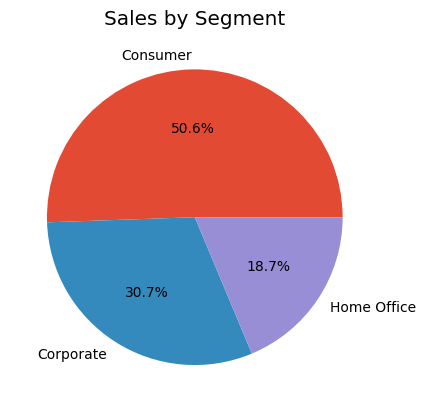

In [73]:
segment_sales = df.groupby("Segment")["Sales"].sum()

segment_sales.plot(kind="pie", autopct="%1.1f%%")

plt.title("Sales by Segment")

plt.ylabel("")

plt.show()

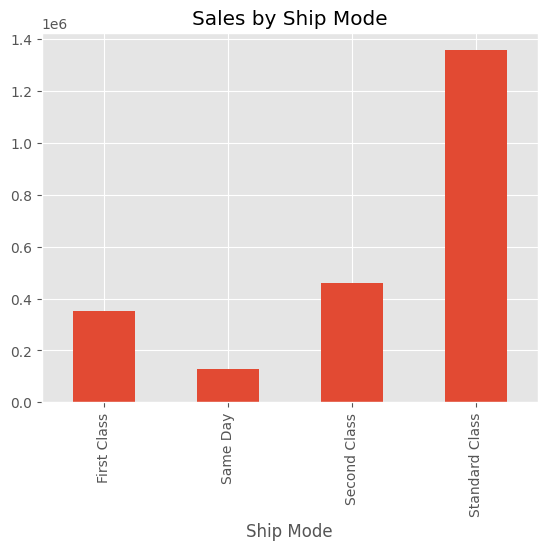

In [74]:
ship_sales = df.groupby("Ship Mode")["Sales"].sum()

ship_sales.plot(kind="bar")

plt.title("Sales by Ship Mode")

plt.show()

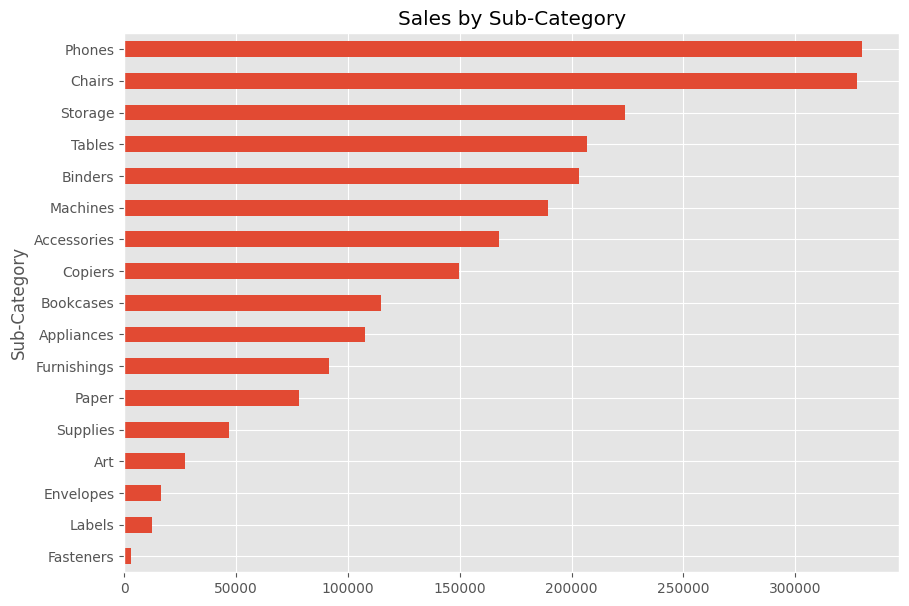

In [75]:
subcategory = df.groupby("Sub-Category")["Sales"].sum().sort_values()

subcategory.plot(kind="barh", figsize=(10,7))

plt.title("Sales by Sub-Category")

plt.show()

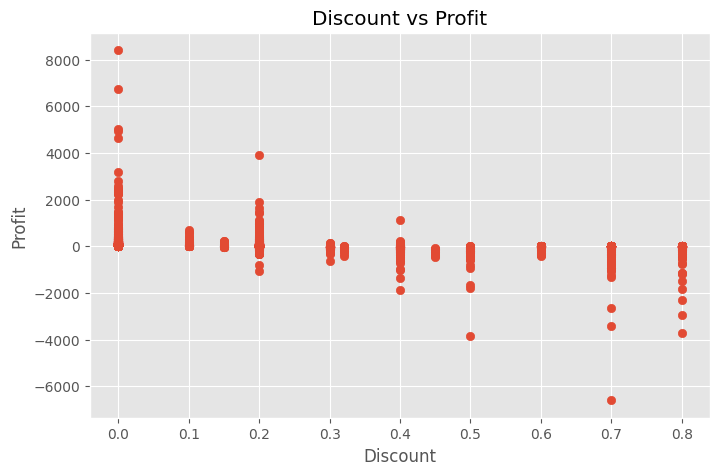

In [76]:
plt.figure(figsize=(8,5))

plt.scatter(df["Discount"], df["Profit"])

plt.xlabel("Discount")

plt.ylabel("Profit")

plt.title("Discount vs Profit")

plt.show()

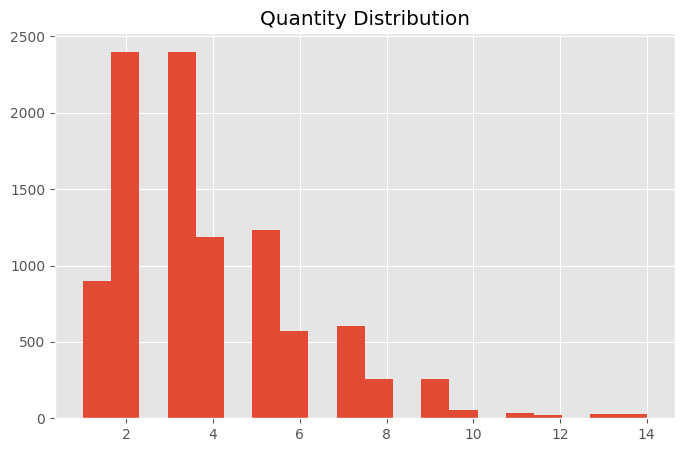

In [77]:
plt.figure(figsize=(8,5))

plt.hist(df["Quantity"], bins=20)

plt.title("Quantity Distribution")

plt.show()

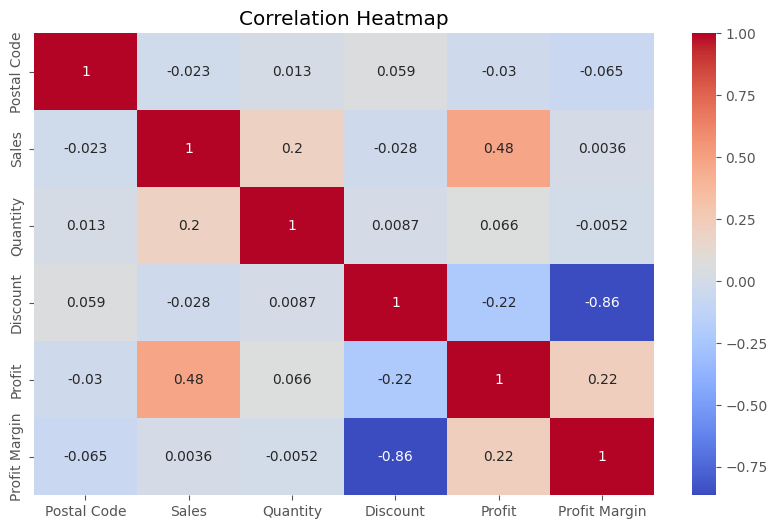

In [78]:
plt.figure(figsize=(10,6))

numeric = df.select_dtypes(include="number")

sns.heatmap(
    numeric.corr(),
    annot=True,
    cmap="coolwarm"
)

plt.title("Correlation Heatmap")

plt.show()

In [79]:
#Best category
print(df.groupby("Category")["Sales"].sum().sort_values(ascending=False))

Category
Technology         836154.0330
Furniture          741306.3133
Office Supplies    718735.2440
Name: Sales, dtype: float64


In [80]:
#Most Profitable Region
print(df.groupby("Region")["Profit"].sum().sort_values(ascending=False))

Region
West       108329.8079
East        91506.3092
South       46749.4303
Central     39655.8752
Name: Profit, dtype: float64


In [81]:
print(df.groupby("City")["Sales"].sum().sort_values(ascending=False).head(10))

City
New York City    256319.0410
Los Angeles      175831.9010
Seattle          119460.2820
San Francisco    112577.1720
Philadelphia     109061.4610
Houston           64441.2564
Chicago           48535.9770
San Diego         47521.0290
Jacksonville      44713.1830
Springfield       43054.3420
Name: Sales, dtype: float64


In [82]:
print(df.groupby("State")["Sales"].sum().sort_values(ascending=False).head(10))

State
California      457576.2715
New York        310827.1510
Texas           170124.5418
Washington      138560.8100
Pennsylvania    116496.3620
Florida          89473.7080
Illinois         80162.5370
Ohio             77976.7640
Michigan         75879.6440
Virginia         70636.7200
Name: Sales, dtype: float64


In [83]:
print(df.groupby("Segment")["Sales"].sum())

Segment
Consumer       1.160833e+06
Corporate      7.060701e+05
Home Office    4.292927e+05
Name: Sales, dtype: float64


In [84]:
print(df.groupby("Ship Mode")["Sales"].sum())

Ship Mode
First Class       3.513805e+05
Same Day          1.283217e+05
Second Class      4.591770e+05
Standard Class    1.357316e+06
Name: Sales, dtype: float64


In [85]:
print(df.groupby("Category")["Profit"].mean())

Category
Furniture           8.697740
Office Supplies    20.353403
Technology         78.752002
Name: Profit, dtype: float64


In [86]:
summary = pd.DataFrame({

    "Total Sales":[df["Sales"].sum()],

    "Total Profit":[df["Profit"].sum()],

    "Average Sales":[df["Sales"].mean()],

    "Average Profit":[df["Profit"].mean()],

    "Total Quantity":[df["Quantity"].sum()]
})

summary.to_csv("output/business_summary.csv", index=False)

summary

,Total Sales,Total Profit,Average Sales,Average Profit,Total Quantity
0,2.296196e+06,286241.4226,230.148902,28.69013,37820


In [87]:
df.to_csv("output/final_dataset.csv", index=False)

print("EDA Completed Successfully")

EDA Completed Successfully


In [88]:
import pandas as pd

# Load final dataset
df = pd.read_csv("output/final_dataset.csv")

print("Dataset Loaded Successfully!")

Dataset Loaded Successfully!


In [89]:
category_sales = (
    df.groupby("Category")
      .agg(
          Total_Sales=("Sales", "sum"),
          Total_Profit=("Profit", "sum"),
          Total_Quantity=("Quantity", "sum")
      )
      .sort_values(by="Total_Sales", ascending=False)
)

print(category_sales)

category_sales.to_csv("output/category_sales.csv")

                 Total_Sales  Total_Profit  Total_Quantity
Category                                                  
Technology       836154.0330   145454.9481            6939
Furniture        741306.3133    18421.8137            8020
Office Supplies  718735.2440   122364.6608           22861


In [90]:
subcategory_sales = (
    df.groupby("Sub-Category")
      .agg(
          Sales=("Sales", "sum"),
          Profit=("Profit", "sum"),
          Quantity=("Quantity", "sum")
      )
      .sort_values(by="Sales", ascending=False)
)

print(subcategory_sales)

subcategory_sales.to_csv("output/subcategory_sales.csv")

                    Sales      Profit  Quantity
Sub-Category                                   
Phones        330007.0540  44515.7306      3289
Chairs        327777.7610  26567.1278      2351
Storage       223843.6080  21278.8264      3158
Tables        206965.5320 -17725.4811      1241
Binders       203409.1690  30228.0003      5971
Machines      189238.6310   3384.7569       440
Accessories   167380.3180  41936.6357      2976
Copiers       149528.0300  55617.8249       234
Bookcases     114879.9963  -3472.5560       868
Appliances    107532.1610  18138.0054      1729
Furnishings    91683.0240  13052.7230      3560
Paper          78224.1420  33944.2395      5144
Supplies       46673.5380  -1189.0995       647
Art            27107.0320   6524.6118      2996
Envelopes      16476.4020   6964.1767       906
Labels         12444.9120   5526.3820      1396
Fasteners       3024.2800    949.5182       914


In [91]:
region_sales = (
    df.groupby("Region")
      .agg(
          Sales=("Sales", "sum"),
          Profit=("Profit", "sum")
      )
      .sort_values(by="Sales", ascending=False)
)

print(region_sales)

region_sales.to_csv("output/region_sales.csv")

               Sales       Profit
Region                           
West     725255.6365  108329.8079
East     678435.1960   91506.3092
Central  500782.8528   39655.8752
South    391721.9050   46749.4303


In [92]:
state_sales = (
    df.groupby("State")
      .agg(
          Sales=("Sales", "sum"),
          Profit=("Profit", "sum")
      )
      .sort_values(by="Sales", ascending=False)
)

print(state_sales)

state_sales.to_csv("output/state_sales.csv")

                            Sales      Profit
State                                        
California            457576.2715  76330.7891
New York              310827.1510  74015.4622
Texas                 170124.5418 -25750.9833
Washington            138560.8100  33368.2375
Pennsylvania          116496.3620 -15565.4035
Florida                89473.7080  -3399.3017
Illinois               80162.5370 -12601.6500
Ohio                   77976.7640 -16959.3178
Michigan               75879.6440  24428.0903
Virginia               70636.7200  18597.9504
North Carolina         55603.1640  -7490.9122
Indiana                53555.3600  18382.9363
Georgia                49095.8400  16250.0433
Kentucky               36591.7500  11199.6966
New Jersey             35764.3120   9772.9138
Arizona                35282.0010  -3427.9246
Wisconsin              32114.6100   8401.8004
Colorado               32108.1180  -6527.8579
Tennessee              30661.8730  -5341.6936
Minnesota              29863.1500 

In [93]:
city_sales = (
    df.groupby("City")
      .agg(
          Sales=("Sales", "sum"),
          Profit=("Profit", "sum")
      )
      .sort_values(by="Sales", ascending=False)
      .head(10)
)

print(city_sales)

city_sales.to_csv("output/top_cities.csv")

                     Sales      Profit
City                                  
New York City  256319.0410  62013.8973
Los Angeles    175831.9010  30431.4267
Seattle        119460.2820  29121.6825
San Francisco  112577.1720  17466.1186
Philadelphia   109061.4610 -13843.2106
Houston         64441.2564 -10175.1755
Chicago         48535.9770  -6648.3318
San Diego       47521.0290   6377.1960
Jacksonville    44713.1830  -2323.8350
Springfield     43054.3420   6200.6974


In [94]:
segment_sales = (
    df.groupby("Segment")
      .agg(
          Sales=("Sales", "sum"),
          Profit=("Profit", "sum")
      )
      .sort_values(by="Sales", ascending=False)
)

print(segment_sales)

segment_sales.to_csv("output/segment_sales.csv")

                    Sales       Profit
Segment                               
Consumer     1.160833e+06  134007.4413
Corporate    7.060701e+05   91954.9798
Home Office  4.292927e+05   60279.0015


In [95]:
shipmode_sales = (
    df.groupby("Ship Mode")
      .agg(
          Sales=("Sales", "sum"),
          Profit=("Profit", "sum")
      )
)

print(shipmode_sales)

shipmode_sales.to_csv("output/shipmode_sales.csv")

                       Sales       Profit
Ship Mode                                
First Class     3.513805e+05   48953.6561
Same Day        1.283217e+05   15871.8869
Second Class    4.591770e+05   57446.6516
Standard Class  1.357316e+06  163969.2280


In [96]:
highest_profit = (
    df.groupby("State")["Profit"]
      .sum()
      .sort_values(ascending=False)
      .head(10)
)

print(highest_profit)

State
California    76330.7891
New York      74015.4622
Washington    33368.2375
Michigan      24428.0903
Virginia      18597.9504
Indiana       18382.9363
Georgia       16250.0433
Kentucky      11199.6966
Minnesota     10823.1874
Delaware       9977.3748
Name: Profit, dtype: float64


In [97]:
lowest_profit = (
    df.groupby("State")["Profit"]
      .sum()
      .sort_values()
      .head(10)
)

print(lowest_profit)

State
Texas            -25750.9833
Ohio             -16959.3178
Pennsylvania     -15565.4035
Illinois         -12601.6500
North Carolina    -7490.9122
Colorado          -6527.8579
Tennessee         -5341.6936
Arizona           -3427.9246
Florida           -3399.3017
Oregon            -1194.0993
Name: Profit, dtype: float64


In [98]:
category_sales.to_csv("dashboard/category_sales.csv")
subcategory_sales.to_csv("dashboard/subcategory_sales.csv")
region_sales.to_csv("dashboard/region_sales.csv")
state_sales.to_csv("dashboard/state_sales.csv")
city_sales.to_csv("dashboard/top_cities.csv")
segment_sales.to_csv("dashboard/segment_sales.csv")
shipmode_sales.to_csv("dashboard/shipmode_sales.csv")

print("Dashboard files exported successfully!")

Dashboard files exported successfully!
